In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%run "hw.ipynb"

In [3]:
import pandas as pd

# List of file paths
file_paths = [
    'data/Lillo_temps/Lillo_1_10_15_to_19_9_18.csv',
    'data/Lillo_temps/Lillo_20_9_18_to_2_2_21.csv',
    'data/Lillo_temps/Lillo_3_2_21_to_19_9_22.csv'
]

# Read and concatenate all files
data_frames = [pd.read_csv(file, sep=',') for file in file_paths]
data = pd.concat(data_frames, ignore_index=True)

# Extract timestamp and temperature columns
times = data['#Timestamp'].tolist()
watertemps = data['Value'].astype(float).tolist()  # Ensuring the temperature values are in float

In [7]:
data['Date'] = data['#Timestamp'].str[:10]

# Calculate the daily average water temperature
daily_avg_watertemp = data.groupby('Date')['Value'].mean().reset_index()
daily_avg_watertemp.columns = ['Date', 'Average_Temperature']

# Create a date-temp. dictionary
daily_avg_watertemp_dict = daily_avg_watertemp.set_index('Date')['Average_Temperature'].to_dict()

In [9]:
from datetime import datetime

# Convert the date strings to datetime objects for accurate filtering
# and create a new dictionary with datetime objects as keys
converted_data = {datetime.strptime(date, '%Y-%m-%d'): temp for date, temp in daily_avg_watertemp_dict.items()}

# Define the cutoff date as a datetime object
cutoff_date = datetime.strptime('2023-12-31', '%Y-%m-%d')

# Filter the data up to and including the cutoff date
filtered_data = {date: temp for date, temp in converted_data.items() if date <= cutoff_date}
filtered_dates = sorted(filtered_data.keys())
filtered_watertemps = [filtered_data[date] for date in filtered_dates]

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4

# Load ERA5-Land data for surface temperature (tas)
tas = xr.open_dataset('data/Lillo_training_data/tas_lillo.nc', engine='netcdf4', mode='r')
tas = tas.resample(time='1D').mean() # Resample to daily temperature data

# Load ERA5-Land data for surface solar radiation downwards (ssrd)
# This should be the accumulated ssrd (J/m^2) at 00:00H, i.e. the daily total
qq = xr.open_dataset('data/Lillo_training_data/ssrd_lillo.nc', engine='netcdf4', mode='r')

# Construct a Dataset instance
# Note that variable 167 corresponds to surface temperature in ERA5-Land
# Note that both TX and TN are defined as TG (we only need about TG for the Tw model)
dataset_train = Dataset(
    tas.time.dt.year.values,
    tas.time.dt.month.values,
    tas.time.dt.day.values,
    tas['var167'].values,
    tas['var167'].values
)
dataset_train.set_all()

# Define start date: October 1st, 2015
start_index = np.where(
    (dataset_train.year == 2015) & 
    (dataset_train.month == 10) & 
    (dataset_train.day == 1)
)[0][0]

# Define end date: September 19th, 2022
end_index = np.where(
    (dataset_train.year == 2022) & 
    (dataset_train.month == 9) & 
    (dataset_train.day == 19)
)[0][0] + 1  # +1 for slicing

# Set array for daily air temperature TG
daily_temps = dataset_train.T[start_index:end_index+1]

# Set array for daily surface solar irradiance
# Note that variable 269 corresponds to ssrd in ERA5-Land
# Note that irradiance is obtained from accumulated radiation by dividing by accumulation time (hourly)
daily_qq = qq['var169'].values[start_index:end_index+1] / 3600

In [13]:
filtered_watertemps = np.array(filtered_watertemps)

# Identify indices where measured TW are not NaN
# NaNs can occur when measurements are missing
non_nan_indices = np.where(~np.isnan(filtered_watertemps))[0]

# Filter both Tw arrays and dates based on these indices
cleaned_watertemps = [filtered_watertemps[i] for i in non_nan_indices]
cleaned_dates = [filtered_dates[i] for i in non_nan_indices]

# Filter arrays for solar irradiance and air temp. based on these indices
cleaned_qq = [daily_qq[i] for i in non_nan_indices]
cleaned_daily_temperatures = [daily_temps[i] for i in non_nan_indices]

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

airtemps = [temp - 273.15 for temp in cleaned_daily_temperatures]

# Convert to DataFrame
df = pd.DataFrame({
    'date': cleaned_dates,
    'air_temp': airtemps,
    'water_temp': cleaned_watertemps,
    'qq': cleaned_qq
})

# Add seasonal terms to the DataFrame
df['day_of_year'] = df['date'].apply(lambda x: x.timetuple().tm_yday)  
df['sin_day'] = -np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_day'] = -np.cos(2 * np.pi * df['day_of_year'] / 365)

# Compute rolling averages for different lag values and add to DataFrame
# Here we only include an average over previous 30 days, but model can be adapted to include multiple such averages by modifying n_values
n_values = [30]
for n in n_values:
    df[f'air_temp_avg_{n}'] = df['air_temp'].rolling(window=n, min_periods=1).mean()

# Train-Test Split
X = df[['air_temp', 'qq', 'sin_day', 'cos_day'] + [f'air_temp_avg_{n}' for n in n_values]]
y = df['water_temp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit a linear regression model with the training set
lr_model = LinearRegression(positive=True)
lr_model.fit(X_train_scaled, y_train)

# Predict with the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate the model using RMSE and R^2
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE = {rmse_lr:.2f}, R² = {r2_lr:.2f}")

Linear Regression RMSE = 0.55, R² = 0.99


In [20]:
# Get the coefficients for each feature
coefficients = lr_model.coef_

# Get the intercept (bias term)
intercept = lr_model.intercept_

# Print the parameter values
print("Intercept (bias):", intercept)
print("Feature Coefficients:")
for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.4f}")


Intercept (bias): 14.166208721071827
Feature Coefficients:
air_temp: 0.3440
qq: 0.1276
sin_day: 1.0822
cos_day: 2.0184
air_temp_avg_30: 3.1599


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4

# Load EURO-CORDEX data
tasmax = xr.open_dataset('data/daily/tasmax/tasmax_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_day_20560101-20601230.nc', engine="netcdf4", mode='r')
tasmin = xr.open_dataset('data/daily/tasmin/tasmin_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_day_20560101-20601230.nc', engine="netcdf4", mode='r')
rsds = xr.open_dataset('data/daily/rsds/rsds_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_day_20560101-20601230.nc')

# Extract data from Lillo gridpoint
tasmax = tasmax.sel(lat=51.308479, lon=4.277567, method='nearest')
tasmin = tasmin.sel(lat=51.308479, lon=4.277567, method='nearest')
rsds = rsds.sel(lat=51.308479, lon=4.277567, method='nearest')

# Extract data for demo year
rsds_mask = rsds.time.dt.year == 2060
rsds = rsds.sel(time=rsds_mask)

tasmax_mask = tasmax.time.dt.year == 2060
tasmax = tasmax.sel(time=tasmax_mask)

tasmin_mask = tasmin.time.dt.year == 2060
tasmin = tasmin.sel(time=tasmin_mask)

tasmax = tasmax.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
tasmin = tasmin.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
rsds = rsds.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)

def replace_nans_with_neighbors(lst):
    """Replaces all NaN values in a list with the average of its two neighboring values."""
    # Convert list to numpy array for easier processing
    arr = np.array(lst, dtype=np.float64)
    
    # Find indices of NaN values
    nan_indices = np.where(np.isnan(arr))[0]
    
    for idx in nan_indices:
        # Ensure there are neighbors to average
        left = idx - 1 if idx > 0 else None
        right = idx + 1 if idx < len(arr) - 1 else None
        
        if left is not None and right is not None and not np.isnan(arr[left]) and not np.isnan(arr[right]):
            arr[idx] = (arr[left] + arr[right]) / 2  # Average of neighbors
        elif left is not None and not np.isnan(arr[left]):  # If only left neighbor exists
            arr[idx] = arr[left]
        elif right is not None and not np.isnan(arr[right]):  # If only right neighbor exists
            arr[idx] = arr[right]
    
    return arr.tolist()

tasmax_lst = replace_nans_with_neighbors(tasmax['tasmax'].values)
tasmin_lst = replace_nans_with_neighbors(tasmin['tasmin'].values)
rsds_lst = replace_nans_with_neighbors(rsds['rsds'].values)

# Compute average daily air temp. as arithmetic mean of TX and TN
tas_list = [(tasmax_lst[i] + tasmin_lst[i]) * 0.5 for i in range(len(tasmax_lst))]

In [27]:
dates_2060 = tasmax.time.dt.date.values
air_temps_2060 = [temp - 273.15 for temp in tas_list]  # Convert from Kelvin to Celsius

# Create 2060 DataFrame
df_2060 = pd.DataFrame({
    'date': dates_2060,
    'air_temp': air_temps_2060,
    'qq' : rsds_lst
})

df_2060['day_of_year'] = df_2060['date'].apply(lambda x: x.timetuple().tm_yday)  # Works for datetime.datetime
df_2060['sin_day'] = -np.sin(2 * np.pi * df_2060['day_of_year'] / 365)
df_2060['cos_day'] = -np.cos(2 * np.pi * df_2060['day_of_year'] / 365)

# Compute rolling averages for future air temps
for n in n_values:
    df_2060[f'air_temp_avg_{n}'] = df_2060['air_temp'].rolling(window=n, min_periods=1).mean()
    
# Ensure df_future only contains the correct features and scale them
df_2060 = df_2060[X.columns]  # Match feature names used during training
df_2060_scaled = scaler.transform(df_2060)

# Calculate 2060 Zeeschelde temperatures using the linear model
water_temps_2060 = lr_model.predict(df_2060_scaled)

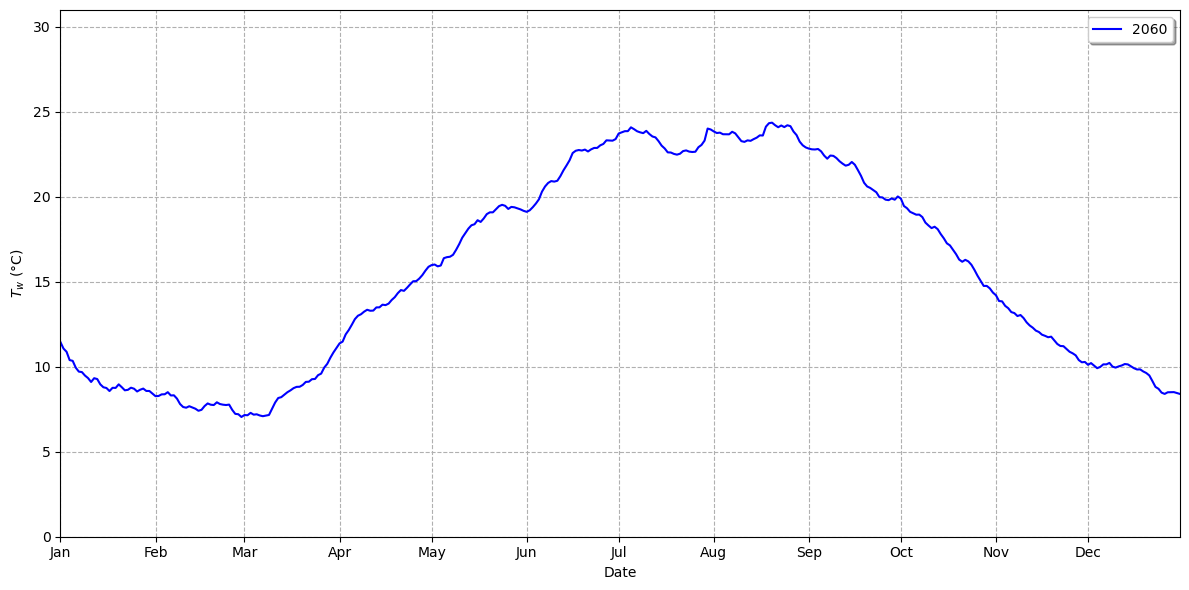

In [30]:
import matplotlib.dates as mdates

# Plot the model results
plt.figure(figsize=(12, 6))
plt.plot(dates_2060, water_temps_2060, c='b', label="2060", linestyle='-')
plt.xlabel("Date")
plt.ylabel(r"$T_w$ (°C)")

# Format x-axis to show abbreviated month names
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(ls='--')
plt.xlim(dates_2060[0], dates_2060[-1])
plt.ylim(0,31)
plt.tight_layout()
plt.legend(fancybox=True, shadow=True)
plt.show()

Calculation of Zeeschelde temperatures for past years such as 1976, 2018 and 2022 is identical using ERA5-Land weather data for those years.